In [74]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy.spatial.transform import Rotation
from scipy.signal import find_peaks
from pathlib import Path

### Get the data

In [75]:
def load_marker_data(file_path: str | Path, tracked_points: None | str | list[str]) -> dict[str, np.ndarray]:
    # Load the raw marker data
    data = pd.read_csv(file_path, header=0, sep="\t")

    # Select columns that contain marker position data
    data = data[[c for c in data.columns if not c.split("_")[-1] in ["n/a", "err"]]]

    # Get all available tracked points
    all_tracked_points = ["_".join(c.split("_")[:-2]) for c in data.columns]
    if not tracked_points:
        tracked_points = all_tracked_points
    elif isinstance(tracked_points, str):
        tracked_points = [tracked_points]
    else:
        pass  # nothing to change

    return {
        tracked_point: data.loc[:, [f"{tracked_point}_POS_{x}" for x in "xyz"]].to_numpy()
        for tracked_point in tracked_points
    }

In [76]:
# Set the path
RAW_DATA_PATH = Path("/home/robbin/Datasets/Keep Control/rawdata")

# Choose a subject and task
sub_id = "pp003"
task_name = "walkSlow"
run_name = None

# Choose markers
tracked_points = [f"{lr}_{mrk}" for lr in "lr" for mrk in ["asis", "psis", "heel", "toe"]]


file_name = f"sub-{sub_id}_task-{task_name}_tracksys-omc_motion.tsv"

markers = load_marker_data(
    file_path=RAW_DATA_PATH / f"sub-{sub_id}" / "motion" / file_name,
    tracked_points=tracked_points
)


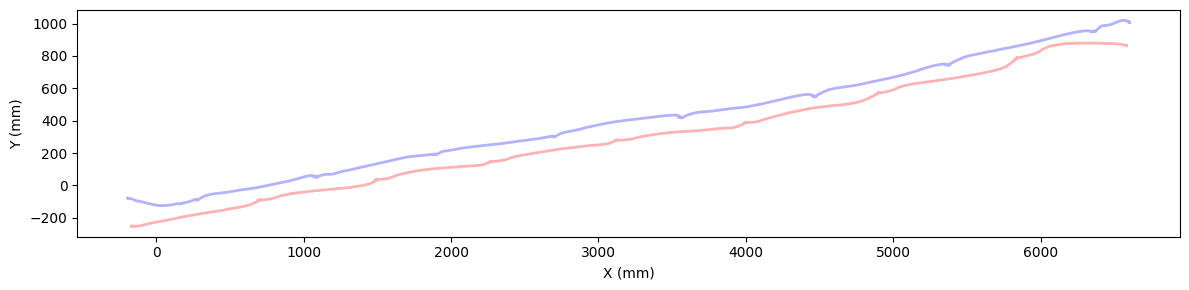

In [77]:
fig, ax = plt.subplots(figsize=(12, 3))
ax.plot(markers["l_heel"][:, 0], markers["l_heel"][:, 1], color="blue", alpha=0.3, lw=2)
ax.plot(markers["r_heel"][:, 0], markers["r_heel"][:, 1], color="red", alpha=0.3, lw=2)
ax.set_xlabel("X (mm)")
ax.set_ylabel("Y (mm)")
ax.set_aspect("auto")
plt.tight_layout()
plt.show()

### Preprocess the data

We will compute virtual markers to represent the mid posterior superior iliac spine (`mid_psis`) and mid anterior superior iliac spine (`mid_asis`). Thoese virtual markers can then be used to estimate the heading, namely the vector pointing from the `mid_psis` to the `mid_asis`. We take the average heading over the entire trial, and rotate all marker trajectories in the horizontal plane such that a forward swing of either leg is associated with a displacement in the +$X$-direction. 

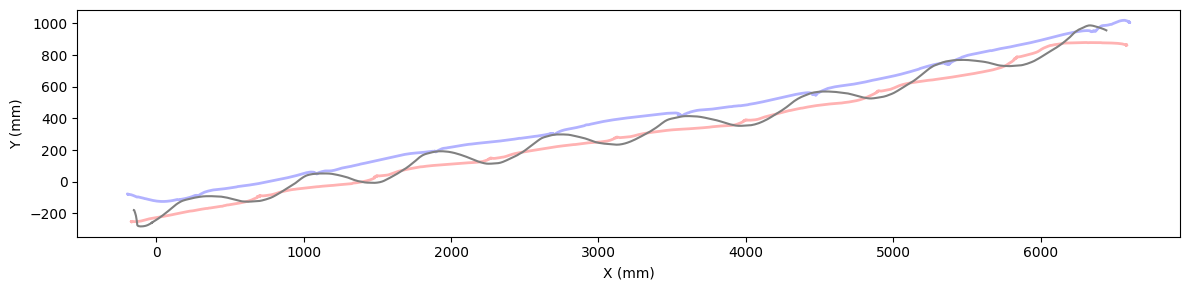

In [78]:
for mrk in ["asis", "psis"]:
    markers[f"mid_{mrk}"] = (markers[f"l_{mrk}"] + markers[f"r_{mrk}"]) / 2.0

fig, ax = plt.subplots(figsize=(12, 3))
ax.plot(markers["l_heel"][:, 0], markers["l_heel"][:, 1], color="blue", alpha=0.3, lw=2)
ax.plot(markers["r_heel"][:, 0], markers["r_heel"][:, 1], color="red", alpha=0.3, lw=2)
ax.plot(markers["mid_psis"][200:-200, 0], markers["mid_psis"][200:-200, 1], color="gray")
ax.set_xlabel("X (mm)")
ax.set_ylabel("Y (mm)")
ax.set_aspect("auto")
plt.tight_layout()
plt.show()

In [79]:
# Detect heel strike and toe off
thr_min_distance = 100  # samples, i.e., 0.5 seconds at 200 Hz
events = dict()
for side in ["l", "r"]:
    signal = markers[f"{side}_heel"][:, 0] - markers[f"mid_psis"][:, 0]
    ipks, _ = find_peaks(signal, distance=thr_min_distance, height=np.nanmean(signal))
    events[f"IC{side.upper()}"] = ipks

    signal = markers[f"{side}_toe"][:, 0] - markers[f"mid_psis"][:, 0]
    ipks, _ = find_peaks(-signal, distance=thr_min_distance, height=np.nanmean(-signal))
    events[f"FC{side.upper()}"] = ipks

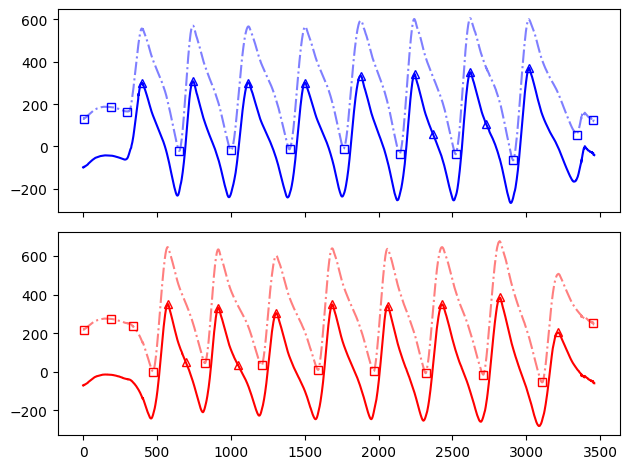

In [80]:
fig, axs = plt.subplots(2, 1, sharex=True)
for row_idx, (mrk, color) in enumerate(zip(["l_heel", "r_heel"], ["blue", "red"])):
    axs[row_idx].plot(markers[mrk][:, 0] - markers["mid_psis"][:, 0], c=color)
    axs[row_idx].plot(markers[mrk.replace("_heel", "_toe")][:, 0] - markers["mid_psis"][:, 0], c=color, alpha=0.5, ls="-.")

    axs[row_idx].plot(
        events[f"IC{mrk[0].upper()}"], 
        markers[mrk][events[f"IC{mrk[0].upper()}"], 0] - markers["mid_psis"][events[f"IC{mrk[0].upper()}"], 0], 
        ls="none", marker="^", mec="b" if mrk[0] == "l" else "r", mfc="none"
    )
    axs[row_idx].plot(
        events[f"FC{mrk[0].upper()}"], 
        markers[mrk.replace("_heel", "_toe")][events[f"FC{mrk[0].upper()}"], 0] - markers["mid_psis"][events[f"FC{mrk[0].upper()}"], 0], 
        ls="none", marker="s", mec="b" if mrk[0] == "l" else "r", mfc="none"
    )
plt.tight_layout()
plt.show()

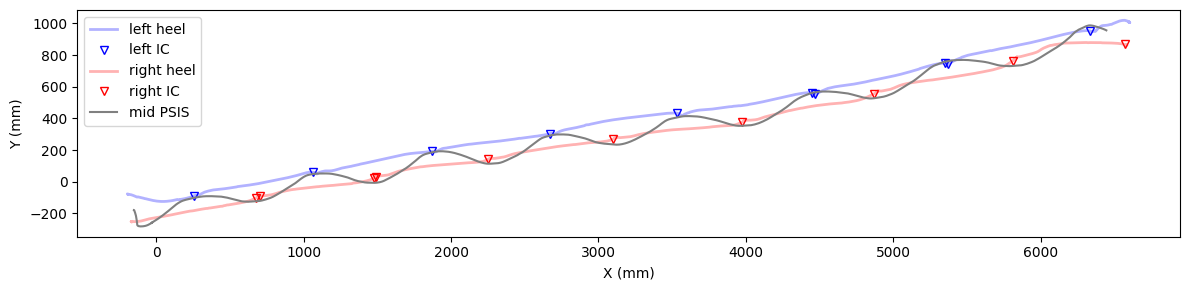

In [81]:
fig, ax = plt.subplots(figsize=(12, 3))
ax.plot(markers["l_heel"][:, 0], markers["l_heel"][:, 1], color="blue", alpha=0.3, lw=2, label="left heel")
ax.plot(markers["l_heel"][events["ICL"], 0], markers["l_heel"][events["ICL"], 1], ls="none", marker="v", mec="b", mfc="none", label="left IC")
ax.plot(markers["r_heel"][:, 0], markers["r_heel"][:, 1], color="red", alpha=0.3, lw=2, label="right heel")
ax.plot(markers["r_heel"][events["ICR"], 0], markers["r_heel"][events["ICR"], 1], ls="none", marker="v", mec="r", mfc="none", label="right IC")
ax.plot(markers["mid_psis"][200:-200, 0], markers["mid_psis"][200:-200, 1], color="gray", label="mid PSIS")
ax.set_xlabel("X (mm)")
ax.set_ylabel("Y (mm)")
ax.legend(loc="best")
ax.set_aspect("auto")
plt.tight_layout()
plt.show()

The step length can be calculated as the scalar product (see: [Scalar product](https://en.wikipedia.org/wiki/Scalar_projection)).

In [82]:
print(f"Left initial contacts:\n{events['ICL']}")
print(f"Right initial contacts:\n{events['ICR']}")

Left initial contacts:
[ 396  744 1118 1502 1878 2244 2368 2622 2729 3018]
Right initial contacts:
[ 573  695  916 1048 1308 1686 2061 2430 2821 3215]


Step width (right to left heel at IC): 204.29 mm
Step length (right to left heel at IC): -364.25 mm


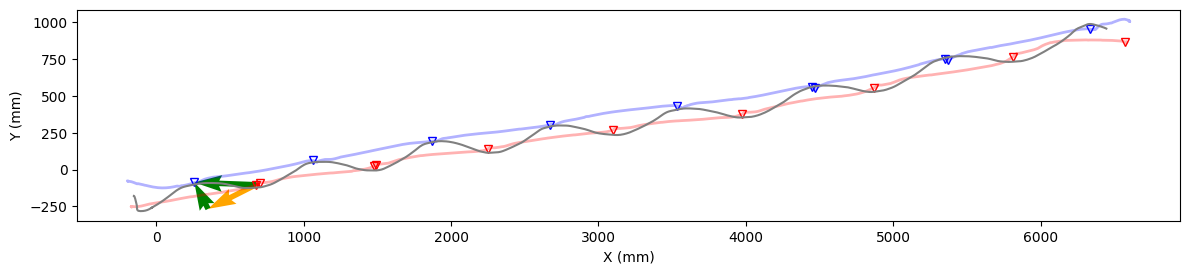

In [83]:
# Displacement vector of the right heel marker
v = markers["r_heel"][events["ICR"][1], :] - markers["r_heel"][events["ICR"][0], :]  # right heel marker

# Displacement vector from right heel marker to left marker marker at left initial contact
u = markers["l_heel"][events["ICL"][0], :] - markers["r_heel"][events["ICR"][0], :]  # vector from right heel to left heel at IC

# Step length is the displacement of the left heel marker along the walking direction (X-axis)
u_v = np.dot(u, v / np.linalg.norm(v)) # project u onto v
u_n = u - u_v * (v / np.linalg.norm(v))  # component of u orthogonal to v
print(f"Step width (right to left heel at IC): {np.linalg.norm(u_n):.2f} mm")
print(f"Step length (right to left heel at IC): {u_v:.2f} mm")

# Visualize
fig, ax = plt.subplots(figsize=(12, 12))
ax.plot(markers["l_heel"][:, 0], markers["l_heel"][:, 1], color="blue", alpha=0.3, lw=2, label="left heel")
ax.plot(markers["l_heel"][events["ICL"], 0], markers["l_heel"][events["ICL"], 1], ls="none", marker="v", mec="b", mfc="none", label="left IC")
ax.plot(markers["r_heel"][:, 0], markers["r_heel"][:, 1], color="red", alpha=0.3, lw=2, label="right heel")
ax.plot(markers["r_heel"][events["ICR"], 0], markers["r_heel"][events["ICR"], 1], ls="none", marker="v", mec="r", mfc="none", label="right IC")
ax.plot(markers["mid_psis"][200:-200, 0], markers["mid_psis"][200:-200, 1], color="gray", label="mid PSIS")
ax.quiver(
    markers["r_heel"][events["ICR"][0], 0],
    markers["r_heel"][events["ICR"][0], 1],
    v[0],
    v[1],
    angles="xy",
    scale_units="xy",
    scale=1,
    color="red",
    width=0.005,
    label="right heel displacement"
)
ax.quiver(
    markers["r_heel"][events["ICR"][0], 0],
    markers["r_heel"][events["ICR"][0], 1],
    u_v * (v / np.linalg.norm(v))[0],
    u_v * (v / np.linalg.norm(v))[1],
    angles="xy",
    scale_units="xy",
    scale=1,
    color="orange",
    width=0.005,
    label="right-to-left heel displacement (step length)"
)
ax.quiver(
    markers["r_heel"][events["ICR"][0], 0] + u_v * (v / np.linalg.norm(v))[0],
    markers["r_heel"][events["ICR"][0], 1] + u_v * (v / np.linalg.norm(v))[1],
    u_n[0],
    u_n[1],
    angles="xy",
    scale_units="xy",
    scale=1,
    color="green",
    width=0.005,
    label="right-to-left heel displacement (step width)"
)
ax.quiver(
    markers["r_heel"][events["ICR"][0], 0],
    markers["r_heel"][events["ICR"][0], 1],
    u[0],
    u[1],
    angles="xy",
    scale_units="xy",
    scale=1,
    color="green",
    width=0.005,
    label="right-to-left heel displacement"
)

ax.set_xlabel("X (mm)")
ax.set_ylabel("Y (mm)")
# ax.legend(loc="best", bbox_to_anchor=(1.05, 1))
ax.set_aspect("equal")
plt.tight_layout()
plt.show()

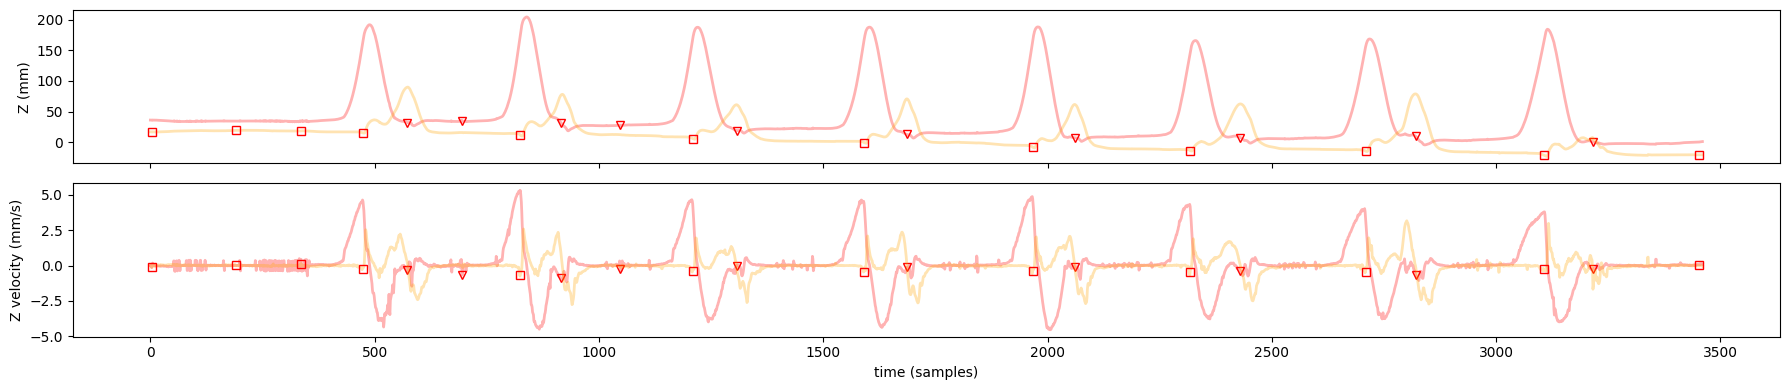

In [84]:
fig, axs = plt.subplots(2, 1, sharex=True, figsize=(18, 4))
# Plot the vertical position of the right heel marker
axs[0].plot(markers["r_heel"][:, 2], color="red", alpha=0.3, lw=2, label="right heel")
axs[0].plot(events["ICR"], markers["r_heel"][events["ICR"], 2], ls="none", marker="v", mec="r", mfc="none", label="right IC")
axs[0].plot(markers["r_toe"][:, 2], color="orange", alpha=0.3, lw=2, label="right toe")
axs[0].plot(events["FCR"], markers["r_toe"][events["FCR"], 2], ls="none", marker="s", mec="r", mfc="none", label="right FC")
axs[0].set_ylabel("Z (mm)")
# Plot the vertical velocity of the right heel marker
vel_right_heel = np.gradient(markers["r_heel"][:, 2])
axs[1].plot(vel_right_heel, color="red", alpha=0.3, lw=2, label="right heel velocity")
axs[1].plot(events["ICR"], vel_right_heel[events["ICR"]], ls="none", marker="v", mec="r", mfc="none", label="right IC")
vel_right_toe = np.gradient(markers["r_toe"][:, 2])
axs[1].plot(vel_right_toe, color="orange", alpha=0.3, lw=2, label="right toe velocity")
axs[1].plot(events["FCR"], vel_right_toe[events["FCR"]], ls="none", marker="s", mec="r", mfc="none", label="right FC")
axs[1].set_ylabel("Z velocity (mm/s)")
axs[1].set_xlabel("time (samples)")
plt.tight_layout()
plt.show()

In [85]:
X = np.isnan(markers["r_heel"]).astype(int)
X

array([[0, 0, 0],
       [0, 0, 0],
       [0, 0, 0],
       ...,
       [0, 0, 0],
       [0, 0, 0],
       [0, 0, 0]], shape=(3461, 3))

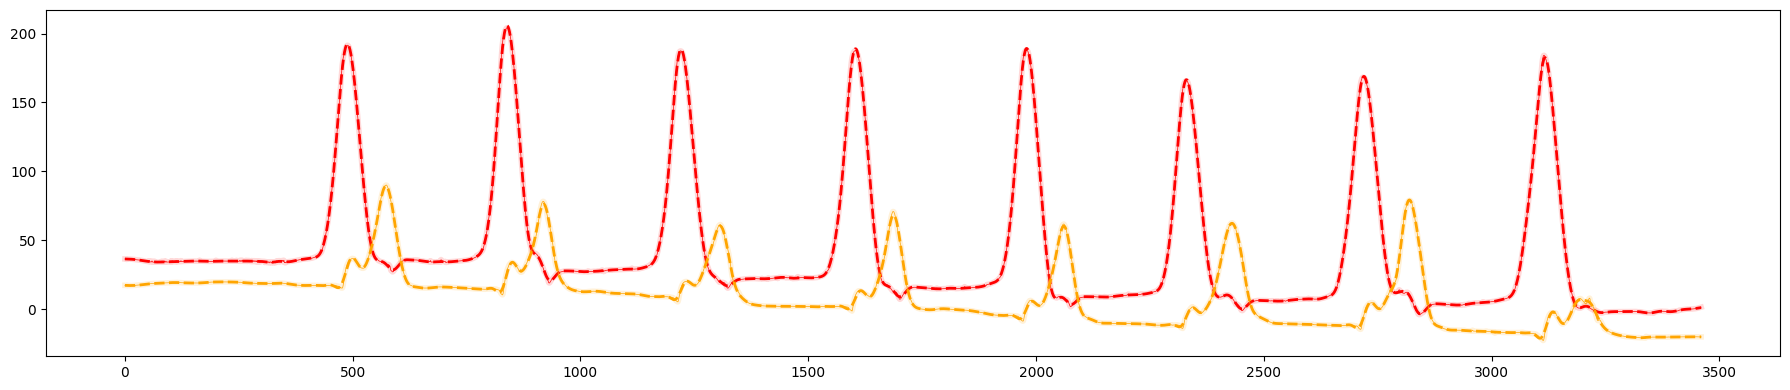

In [86]:
def _interpolate(data: np.ndarray, axis: int = 0) -> np.ndarray:
    from scipy.interpolate import interp1d  # CubicSpline, make_interp_spline
    x = np.arange(data.shape[axis])
    y = data.copy()
    x = x[~np.any(np.isnan(y), axis=1)]
    y = y[~np.any(np.isnan(y), axis=1)]
    f = interp1d(x, y, kind="linear", axis=axis)
    interpolated_data = f(np.arange(data.shape[axis]))
    return interpolated_data

def _lowpass_filter(data: np.ndarray, fs: float, cutoff: float, order: int = 4, axis: int = 0) -> np.ndarray:
    from scipy.signal import butter, filtfilt
    nyq = 0.5 * fs
    normal_cutoff = cutoff / nyq
    b, a = butter(order, normal_cutoff, btype="low", analog=False)
    filtered_data = filtfilt(b, a, data, axis=axis, padtype="odd", padlen=3 * (max(len(b), len(a)) - 1))
    return filtered_data

interpolated_data, filtered_data = dict(), dict()
for mrk in ["r_heel", "r_toe"]:
    interpolated_data[mrk] = _interpolate(markers[mrk], axis=0)
    filtered_data[mrk] = _lowpass_filter(interpolated_data[mrk], fs=200.0, cutoff=6.0, order=4, axis=0)

fig, axs = plt.subplots(figsize=(18, 4))
for mrk, color in zip(["r_heel", "r_toe"], ["red", "orange"]):
    axs.plot(interpolated_data[mrk][:, 2], c=color, lw=4, alpha=0.15, label=f"`{mrk}` interpolated")
    axs.plot(filtered_data[mrk][:, 2], c=color, ls="--", lw=2, label=f"`{mrk}` filtered")
    axs.plot(markers[mrk][:, 2], c=color, ls="-", lw=0.5, label=f"`{mrk}` original")
plt.tight_layout()
plt.show()